## Main Calculation
Checkpoint results are stored in `outputs/logs/` at regular intervals, `save_interval`.


In [1]:
import sys
sys.path.append('../src')

In [2]:
import jax
import jax.numpy as jnp
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
from pinn.cryoet_io import load_mrc_data
import pickle
from flax.training import checkpoints
from pinn.utils import initial_loss
from pinn.train import train_step
from tqdm.notebook import trange

GRID_SIZE = 64
NUM_CHECKPOINTS_TO_KEEP = 1000  # Checkpoint retention count (older ones get removed)

# Set loss function weights
lambda_1 = 5000000    # Weight for boundary loss
lambda_2 = 0          # Weight for physics loss


# Initialize JAX random key
key = jax.random.PRNGKey(0)
# 
# Set directory for initial condition
# ckpt_dir = os.path.abspath(f"../outputs/logs/test_phase/snwitch2-2/30000/default")
# ckpt_dir = os.path.abspath(f"../outputs/logs/biconcave/round_1/lambda_5000000_1e-05/checkpoint_30000/")
# init_ckpt = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

# Create train state
# state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, sdf_pretrain=False, learning_rate=1e-3, init_ckpt=init_ckpt)
state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, sdf_pretrain=True, learning_rate=1e-3)
print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}")

# Load MRC data
mrc_file_path = "../data/synthetic/biconcave.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
print("MRC data loaded successfully! Shape:", cryoET_data.shape)
print("Cryo-ET Data Shape:", cryoET_data.shape)
print("Cryo-ET Data Min:", cryoET_data.min())
print("Cryo-ET Data Max:", cryoET_data.max())
print("Cryo-ET Unique Values:", jnp.unique(cryoET_data))

# Training Data
num_collocation = 1000
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3


# Training loop
num_steps = 1000
save_interval = 20
# num_steps = 30000
# save_interval = 1000

# num_steps = 90000
# save_interval = 1000

# temporary 
binary_mask = jnp.where(cryoET_data > 0.8, 1, 0)
membrane_indices = jnp.where(binary_mask.ravel() == 1)[0]

checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")

checkpoints.save_checkpoint(
    ckpt_dir=checkpoint_dir,
    # target={"state": state, "loss": initial_loss(state, x_train, cryoET_data)},
    target={"state": state, "loss": initial_loss(state, x_train, cryoET_data, membrane_indices)},
    step=0,
    overwrite=False, 
    keep=NUM_CHECKPOINTS_TO_KEEP,
)
loss_history = []


# for step in range(num_steps):
for step in trange(num_steps):
    # state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data)
    state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data, membrane_indices)

    loss_history.append({
        "step": step + 1,
        "total_loss": loss_val,
        "data_loss": loss_data_val,
        "physics_loss": loss_physics_val
    })

    if (step+1) % save_interval == 0:

        loss_history = {key: np.array([entry[key] for entry in loss_history]) for key in loss_history[0].keys()}
        
        checkpoints.save_checkpoint(
            ckpt_dir = checkpoint_dir,
            target={"state": state, "loss": loss_history},
            step=step+1, 
            overwrite=False, 
            keep=NUM_CHECKPOINTS_TO_KEEP,
        )
        print(f"Checkpoint saved at step {step+1}")

        loss_history = []


Pretraining the network using SDF...
Using lambda_1: 5000000, lambda_2: 0
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.0
Cryo-ET Data Max: 0.94504917
Cryo-ET Unique Values: [0.0000000e+00 1.0223870e-20 2.0447740e-20 ... 9.4461203e-01 9.4485116e-01
 9.4504917e-01]


  0%|          | 0/1000 [00:00<?, ?it/s]

Checkpoint saved at step 20
Checkpoint saved at step 40
Checkpoint saved at step 60
Checkpoint saved at step 80
Checkpoint saved at step 100
Checkpoint saved at step 120
Checkpoint saved at step 140
Checkpoint saved at step 160
Checkpoint saved at step 180
Checkpoint saved at step 200
Checkpoint saved at step 220
Checkpoint saved at step 240
Checkpoint saved at step 260
Checkpoint saved at step 280
Checkpoint saved at step 300
Checkpoint saved at step 320
Checkpoint saved at step 340
Checkpoint saved at step 360
Checkpoint saved at step 380
Checkpoint saved at step 400
Checkpoint saved at step 420
Checkpoint saved at step 440
Checkpoint saved at step 460
Checkpoint saved at step 480
Checkpoint saved at step 500
Checkpoint saved at step 520
Checkpoint saved at step 540
Checkpoint saved at step 560
Checkpoint saved at step 580
Checkpoint saved at step 600
Checkpoint saved at step 620
Checkpoint saved at step 640
Checkpoint saved at step 660
Checkpoint saved at step 680
Checkpoint saved a

## Analysis

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/lambda_5000000_0


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (128, 128, 128) to (64, 64, 64)


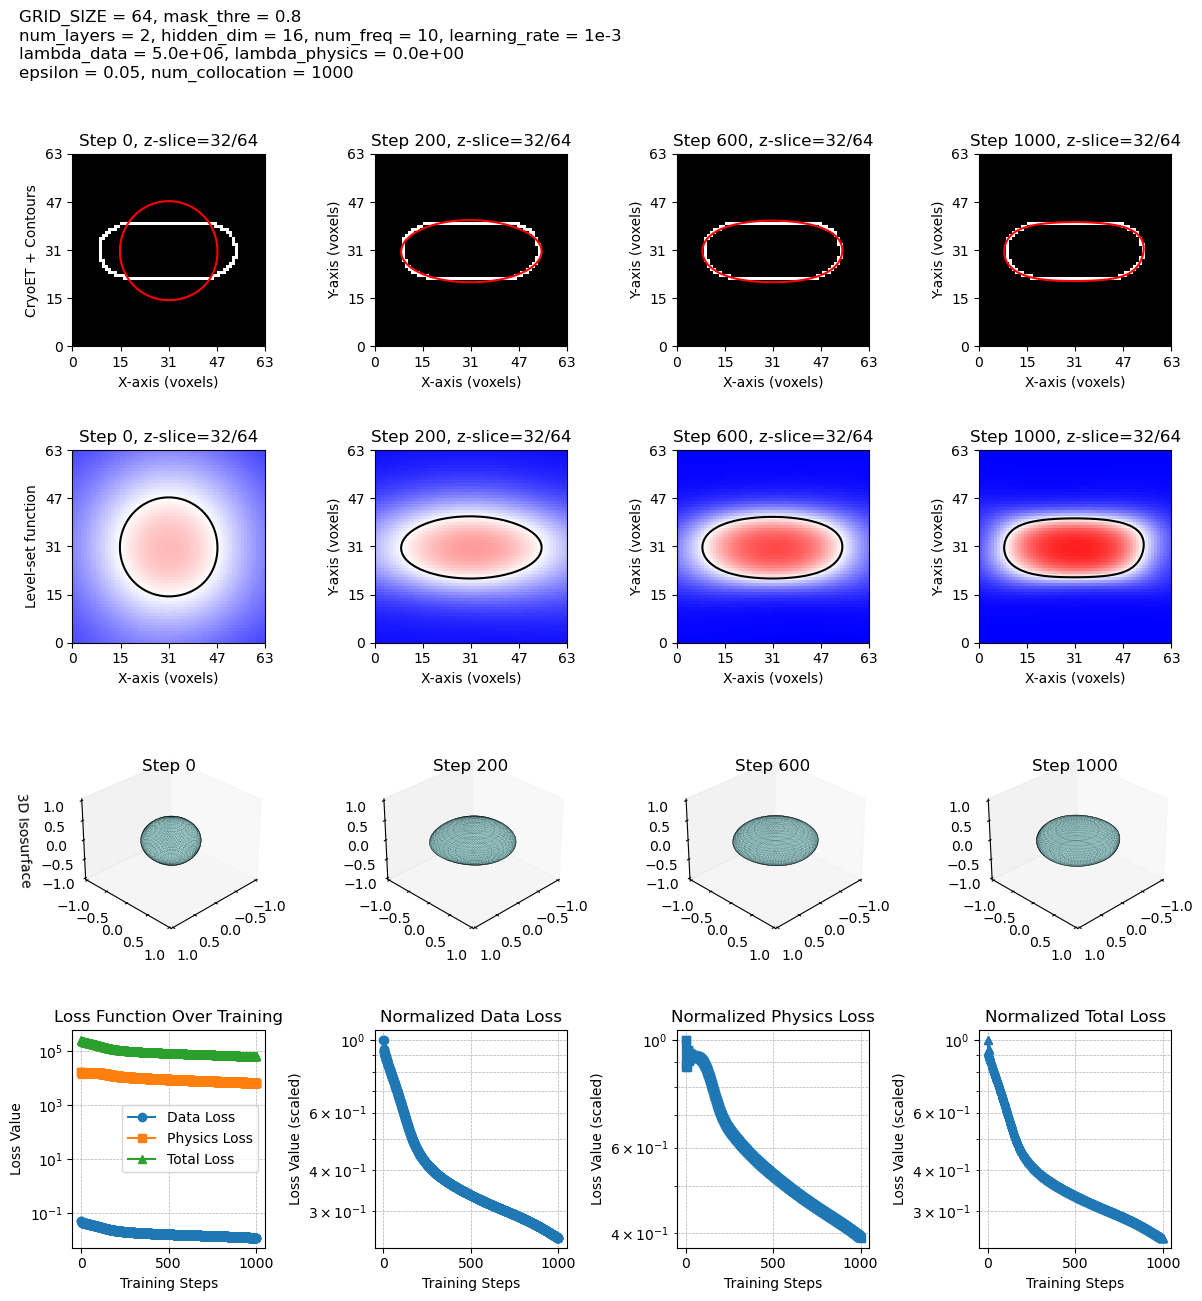

In [3]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 5000000
# lambda_2 = 1
num_collocation = 1000
num_layers = 2

# steps_to_visualize = [0, 20, 60, 100]
# steps_series = list(range(0, 101, 20))
steps_to_visualize = [0, 200, 600, 1000]
steps_series = list(range(0, 1001, 20))
# steps_to_visualize = [0, 10000, 20000, 30000]
# steps_series = list(range(0, 30001, 1000))

# steps_to_visualize = [0, 30000, 60000, 90000]
# steps_series = list(range(0, 90001, 1000))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = "../data/synthetic/biconcave.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


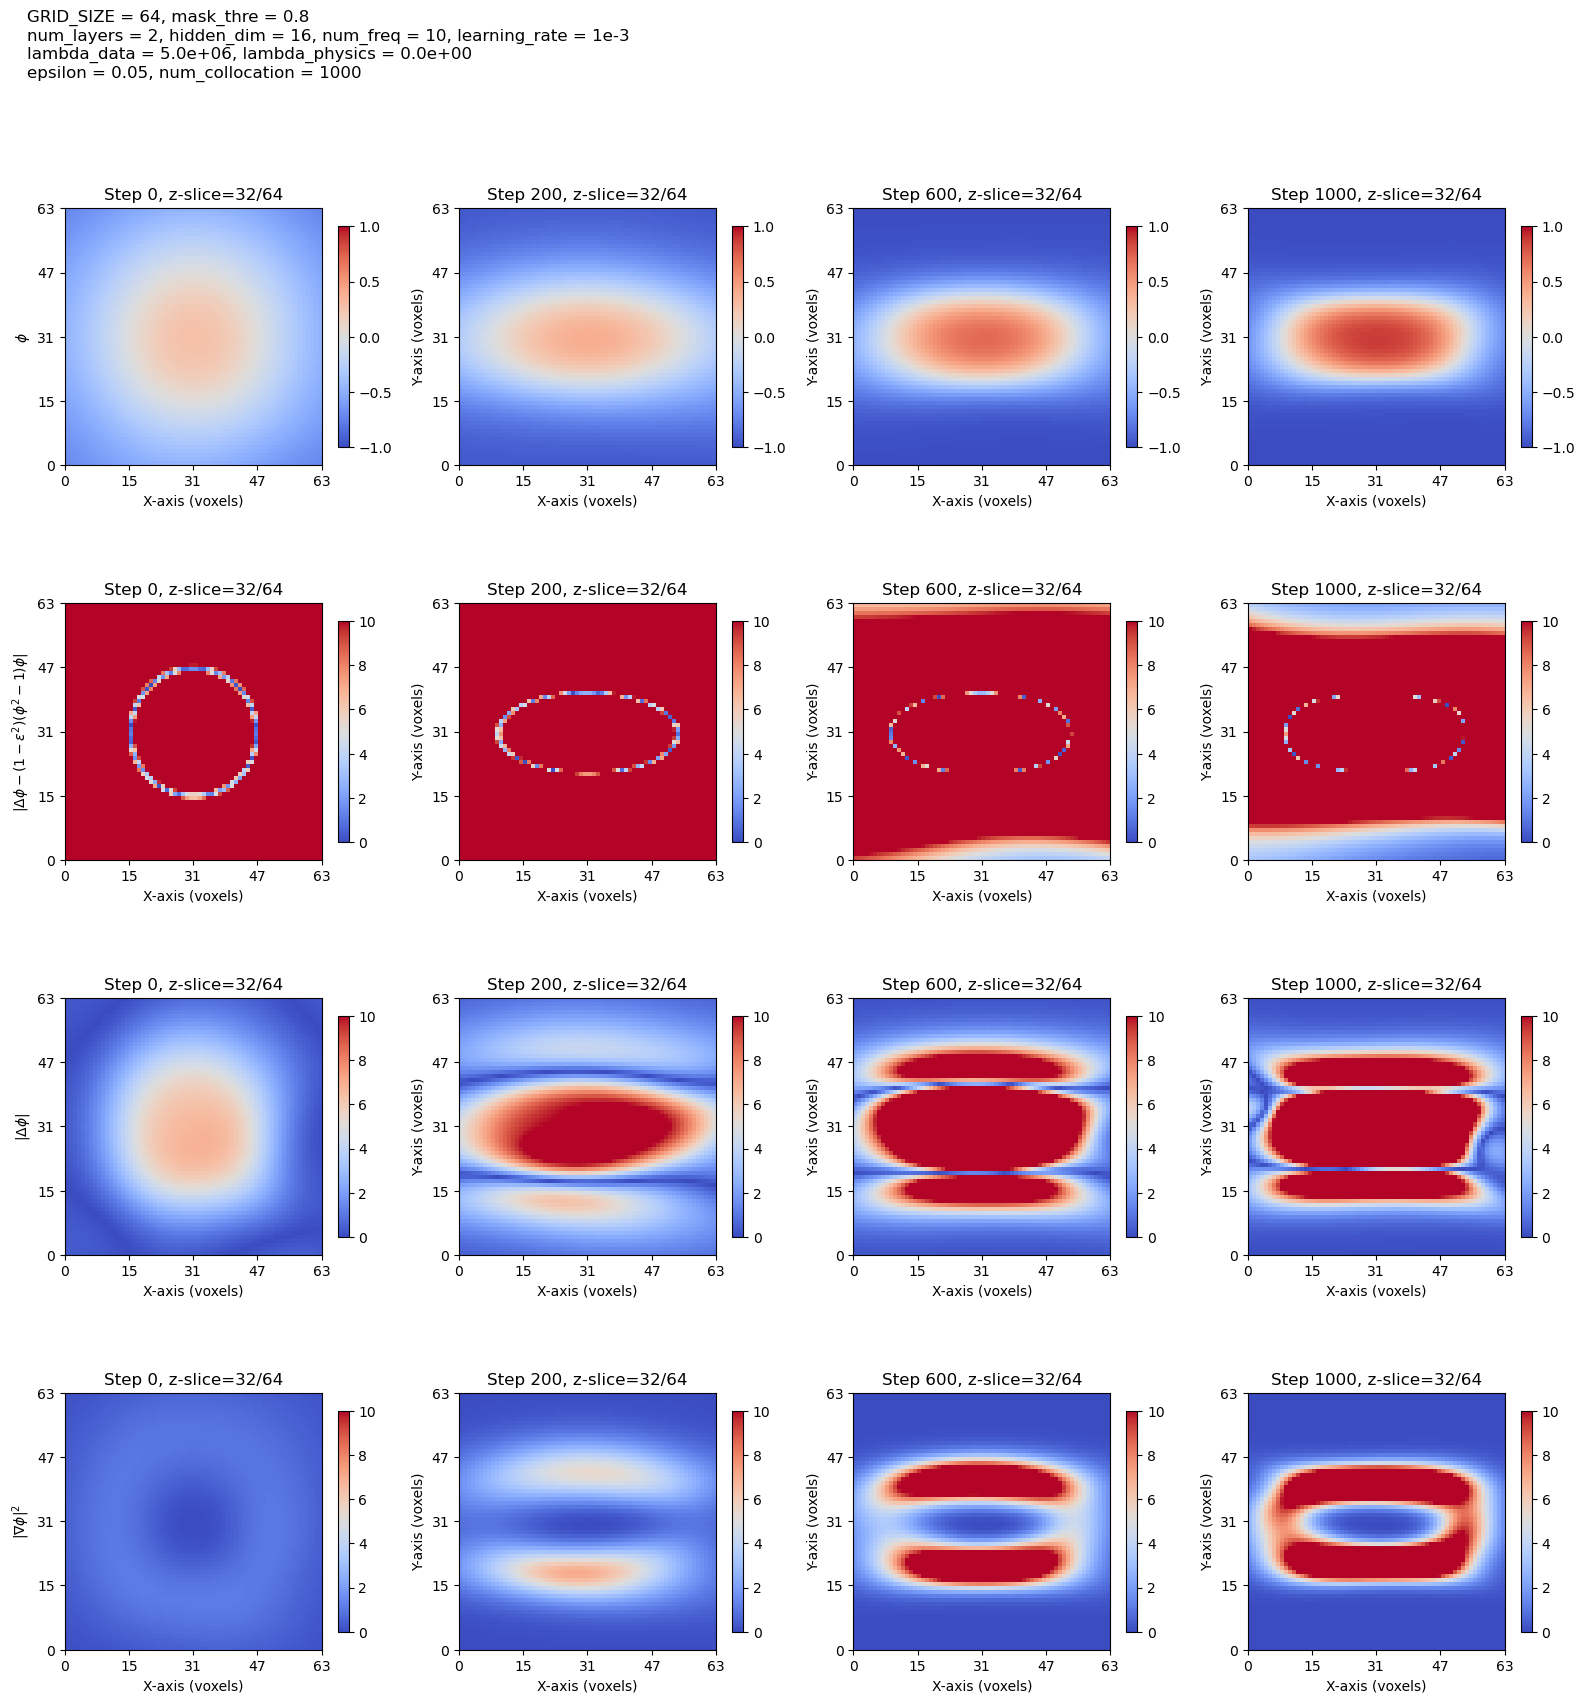

In [6]:
## make one combined physics analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# GRID_SIZE = 100
# lambda_1 = 500
# lambda_2 = 1e-4
num_collocation = 1000
num_layers = 2
epsilon = 0.05

steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 10000, 20000, 30000]
# steps_to_visualize = [0, 30000, 60000, 90000]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: residual
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=10)
    # visualize_physics_loss(ax, step, checkpoint_data[step], epsilon = epsilon, component = "residual", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e5)
    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1-\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 3: laplacian
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="laplacian",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=10)
    # visualize_physics_loss(ax, step, checkpoint_data[step], epsilon = epsilon, component = "laplacian", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e5)
    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi|$")

# Row 4: gradient
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="grad_norm2",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=10)
    # visualize_physics_loss(ax, step, checkpoint_data[step], epsilon = epsilon, component = "nonlinear", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=0.4)
    if i == 0:
        # ax.set_ylabel(r"$|(\phi^2 - 1)\phi|$")
        ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()

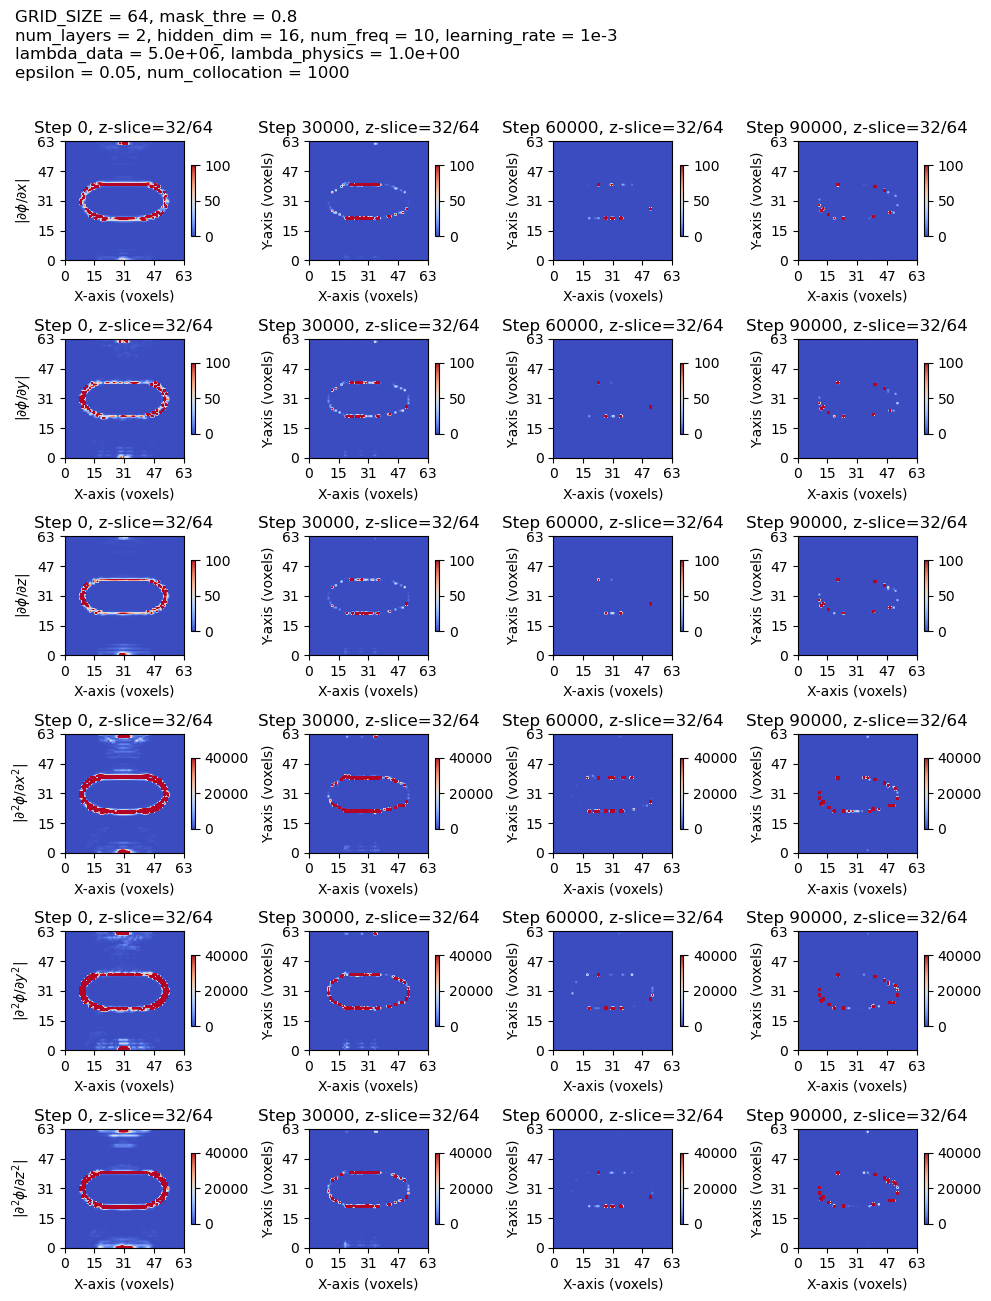

In [10]:
## make one combined derivative analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 5000000.0
# lambda_2 = 1e-5
# num_collocation = 1000
num_layers = 2
epsilon = 0.05

# steps_to_visualize = [0, 200, 600, 1000]
steps_to_visualize = [0, 30000, 60000, 90000]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(2.5*4, 2*6))


# Row 2: grad_x
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(6, 4, i + 1)
    visualize_physics_loss(ax, epsilon = 0.05, step=step, checkpoint=checkpoint_data[step], component = "grad_x", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e2)
    if i == 0:
        ax.set_ylabel(r"$|\partial \phi / \partial x|$")

# Row 3: grad_y
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(6, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon = 0.05, step=step, checkpoint=checkpoint_data[step], component = "grad_y", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e2)
    if i == 0:
        ax.set_ylabel(r"$|\partial \phi / \partial y|$")

# Row 4: grad_z
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(6, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon = 0.05, step=step, checkpoint=checkpoint_data[step], component = "grad_z", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e2)
    if i == 0:
        ax.set_ylabel(r"$|\partial \phi / \partial z|$")

# Row 5: hess_xx
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(6, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon = 0.05, step=step, checkpoint=checkpoint_data[step], component = "hess_xx", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=4e4)
    if i == 0:
        ax.set_ylabel(r"$|\partial^2 \phi / \partial x^2|$")

# Row 6: hess_yy
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(6, 4, 16 + i + 1)
    visualize_physics_loss(ax, epsilon = 0.05, step=step, checkpoint=checkpoint_data[step], component = "hess_yy", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=4e4)
    if i == 0:
        ax.set_ylabel(r"$|\partial^2 \phi / \partial y^2|$")

# Row 7: hess_zz
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(6, 4, 20 + i + 1)
    visualize_physics_loss(ax, epsilon = 0.05, step=step, checkpoint=checkpoint_data[step], component = "hess_zz", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=4e4)
    if i == 0:
        ax.set_ylabel(r"$|\partial^2 \phi / \partial z^2|$")

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/grad.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# Make a movie

import matplotlib.pyplot as plt
import os
from pinn.plot import plot_3d_isosurface
from flax.training import checkpoints
import imageio
import re

steps_to_visualize = list(range(0, 30001, 1000))
log_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}/")
frame_dir = os.path.join(log_dir, f"frames")

def save_isosurface_frame(step, checkpoint, save_dir="frames", grid_size=64):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint, grid_size)
    
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def make_movie_from_frames(frame_dir="frames", output="movie.mp4", fps=12, start=0, end=30000):
    # Match files like frame_XXXX.png and extract the numeric part
    pattern = re.compile(r"frame_(\d+)\.png")

    frames = []
    for fname in os.listdir(frame_dir):
        match = pattern.match(fname)
        if match:
            index = int(match.group(1))
            if start <= index <= end:
                frames.append((index, os.path.join(frame_dir, fname)))

    frames.sort(key=lambda x: x[0])

    with imageio.get_writer(output, fps=fps) as writer:
        for _, frame_path in frames:
            image = imageio.imread(frame_path)
            writer.append_data(image)

for step in steps_to_visualize:
    ckpt_path = os.path.join(log_dir, f"checkpoint_{step}")
    ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
    print(f"saving step {step}")
    save_isosurface_frame(step, ckpt_data, save_dir=frame_dir)

output=os.path.abspath(f"{frame_dir}/movie.mp4")
make_movie_from_frames(frame_dir=frame_dir, output=output)

/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


saving step 0
saving step 1000
saving step 2000
saving step 3000
saving step 4000
saving step 5000
saving step 6000
saving step 7000
saving step 8000
saving step 9000
saving step 10000
saving step 11000
saving step 12000
saving step 13000
saving step 14000
saving step 15000
saving step 16000
saving step 17000
saving step 18000
saving step 19000
saving step 20000
saving step 21000
saving step 22000
saving step 23000
saving step 24000
saving step 25000
saving step 26000
saving step 27000
saving step 28000
saving step 29000
saving step 30000


/tmp/ipykernel_47702/3018667548.py:40: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)
/gscratch/matsulab/env/pinn-env/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


## Individual plot

/Users/atsushi/simulation/pinn-exploration-model/venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (128, 128, 128) to (64, 64, 64)


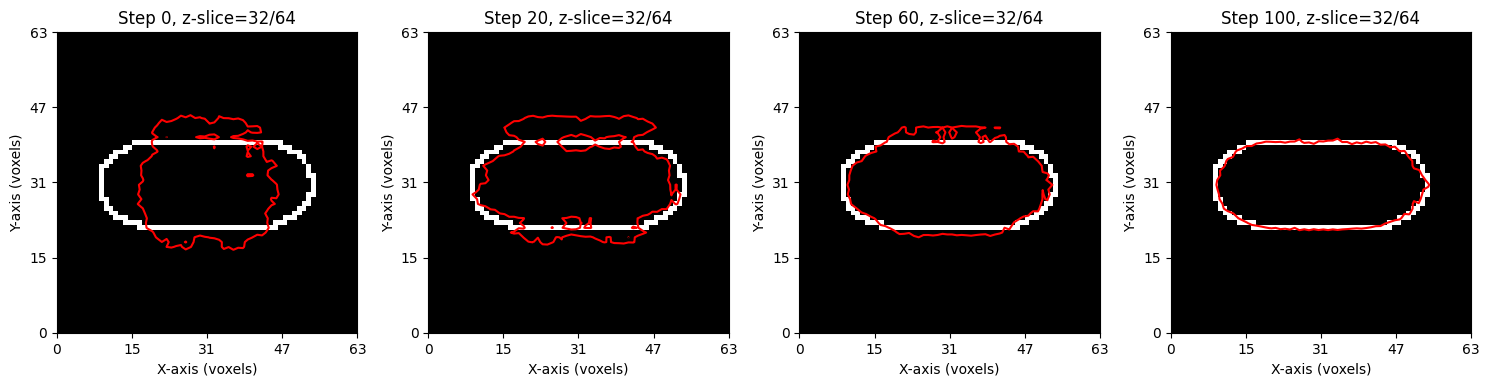

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import visualize_checkpoint_result, visualize_cryoET_with_contours

GRID_SIZE = 64
# lambda_1 = 5000000.0 # Weight for data loss
# lambda_2 = 0.0001 # Weight for physics loss

# Define the checkpoint steps to visualize
# steps_to_visualize = [0, 20, 40, 60]
steps_to_visualize = [0, 20, 60, 100]
# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 60, 180, 300]
# steps_to_visualize = [0, 100, 300, 500]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Create a figure with horizontally arranged subplots
fig, axes = plt.subplots(1, len(steps_to_visualize), figsize=(15, 5))

# Load CryoET data (modify based on your dataset)
mrc_file_path = "../data/synthetic/biconcave.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=64)

# Load and visualize results for different steps
for i, step in enumerate(steps_to_visualize):
    visualize_cryoET_with_contours(axes[i], step, checkpoint_data[step], cryoET_data = cryoET_data, grid_size = GRID_SIZE, slice_index=32, axis="z")

plt.tight_layout()
plt.show()


/Users/atsushi/simulation/pinn-exploration-model/venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (128, 128, 128) to (64, 64, 64)


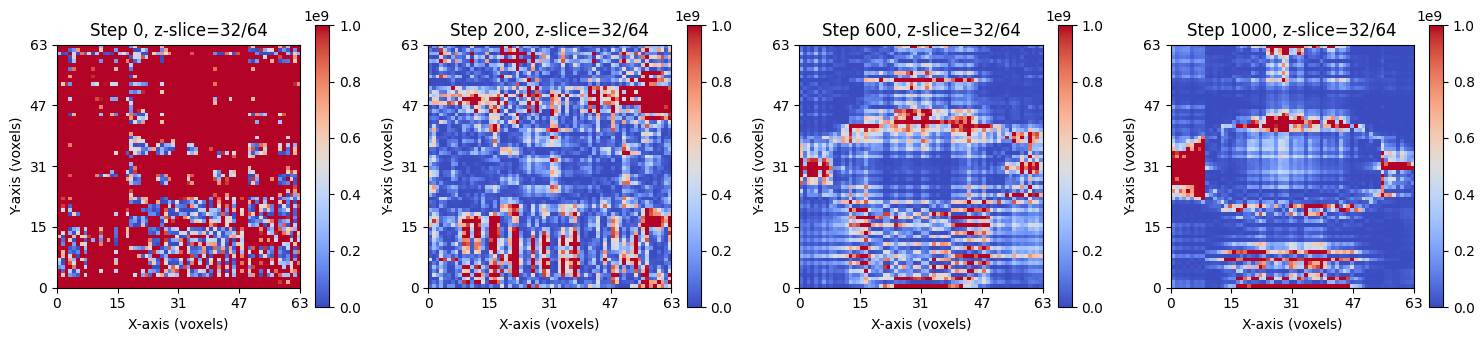

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import visualize_physics_loss

GRID_SIZE = 64
lambda_1 = 5000000.0 # Weight for data loss
lambda_2 = 1e-5 # Weight for physics loss

# Define the checkpoint steps to visualize
# steps_to_visualize = [0, 20, 60, 100]
steps_to_visualize = [0, 200, 600, 1000]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Create a figure with horizontally arranged subplots
fig, axes = plt.subplots(1, len(steps_to_visualize), figsize=(15, 5))

# Load CryoET data (modify based on your dataset)
mrc_file_path = "../data/synthetic/biconcave.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=64)

# Load and visualize results for different steps
for i, step in enumerate(steps_to_visualize):
    # visualize_physics_loss(axes[i], step, checkpoint_data[step], epsilon = 0.05, component = "residual", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e10)
    # visualize_physics_loss(axes[i], step, checkpoint_data[step], epsilon = 0.05, component = "laplacian", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e10)
    # visualize_physics_loss(axes[i], step, checkpoint_data[step], epsilon = 0.05, component = "nonlinear", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=0.15)
    # visualize_physics_loss(axes[i], step, checkpoint_data[step], epsilon = 0.05, component = "grad_x", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e4)
    # visualize_physics_loss(axes[i], step, checkpoint_data[step], epsilon = 0.05, component = "grad_y", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e4)
    # visualize_physics_loss(axes[i], step, checkpoint_data[step], epsilon = 0.05, component = "grad_z", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e4)
    # visualize_physics_loss(axes[i], step, checkpoint_data[step], epsilon = 0.05, component = "hess_xx", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax = 1e9)
    # visualize_physics_loss(axes[i], step, checkpoint_data[step], epsilon = 0.05, component = "hess_yy", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax = 1e9)
    visualize_physics_loss(axes[i], step, checkpoint_data[step], epsilon = 0.05, component = "hess_zz", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax = 1e9)


plt.tight_layout()
plt.show()


In [6]:
import sys
sys.path
os.getcwd()

'/Users/atsushi/simulation/pinn-exploration-model/notebooks'

/Users/atsushi/simulation/pinn-exploration-model/venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


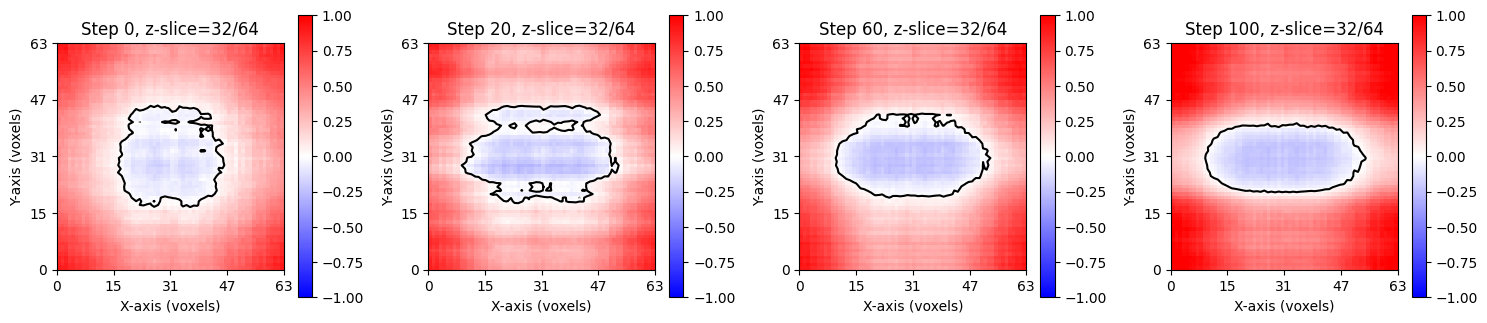

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.plot import visualize_checkpoint_result

GRID_SIZE = 64
lambda_1 = 5000000.0  # Weight for data loss
lambda_2 = 1e-5    # Weight for physics loss

# steps_to_visualize = [0, 20, 40, 60]
steps_to_visualize = [0, 20, 60, 100]
# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 60, 180, 300]
# steps_to_visualize = [0, 100, 300, 500]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Create a figure with horizontally arranged subplots
fig, axes = plt.subplots(1, len(steps_to_visualize), figsize=(15, 5))

for i, step in enumerate(steps_to_visualize):
    visualize_checkpoint_result(axes[i], step, checkpoint_data[step], grid_size = GRID_SIZE, slice_index=32, axis="z")


# Adjust layout and add colorbar
# fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02)
plt.tight_layout()
plt.show()

/Users/atsushi/simulation/pinn-exploration-model/venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


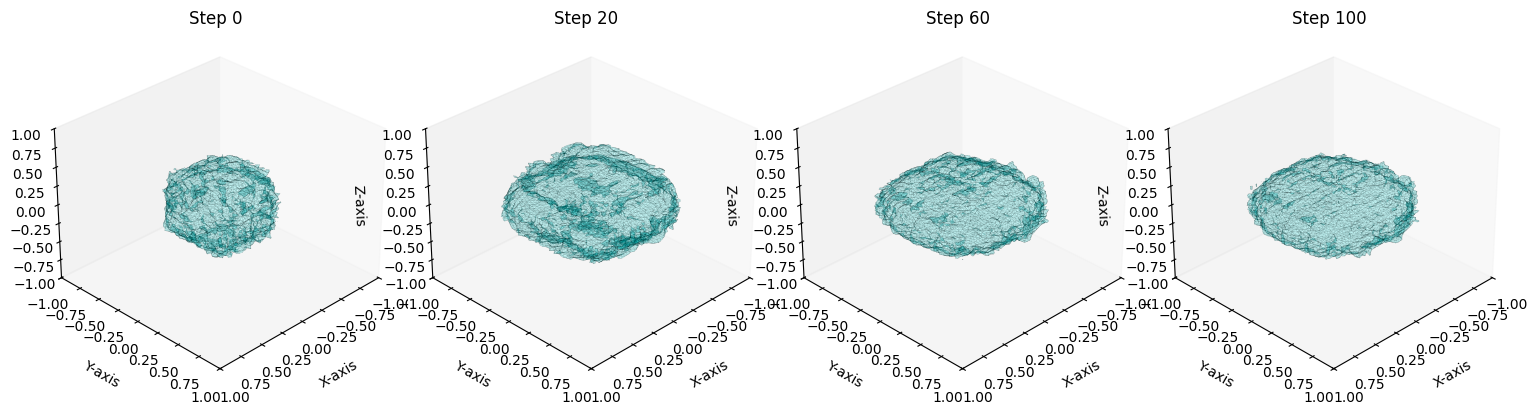

In [11]:
import numpy as np
import os
import jax.numpy as jnp
import matplotlib.pyplot as plt
from pinn.model import PINN
from flax.training import checkpoints
from pinn.plot import plot_3d_isosurface

GRID_SIZE = 64
# lambda_1 = 50000.0  # Weight for data loss
# lambda_2 = 0.000    # Weight for physics loss

# steps_to_visualize = [0, 20, 40, 60]
steps_to_visualize = [0, 20, 60, 100]
# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 60, 180, 300]
# steps_to_visualize = [0, 100, 300, 500]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Create a figure with horizontally arranged subplots
fig, axes = plt.subplots(1, len(steps_to_visualize), figsize=(15, 5), subplot_kw={'projection': '3d'})

for i, step in enumerate(steps_to_visualize):
    plot_3d_isosurface(axes[i], step, checkpoint_data[step], grid_size = GRID_SIZE)

plt.tight_layout()
plt.show()



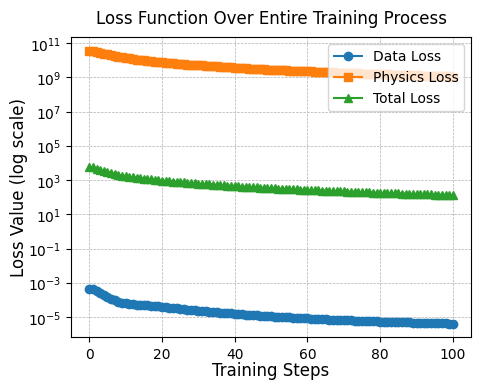

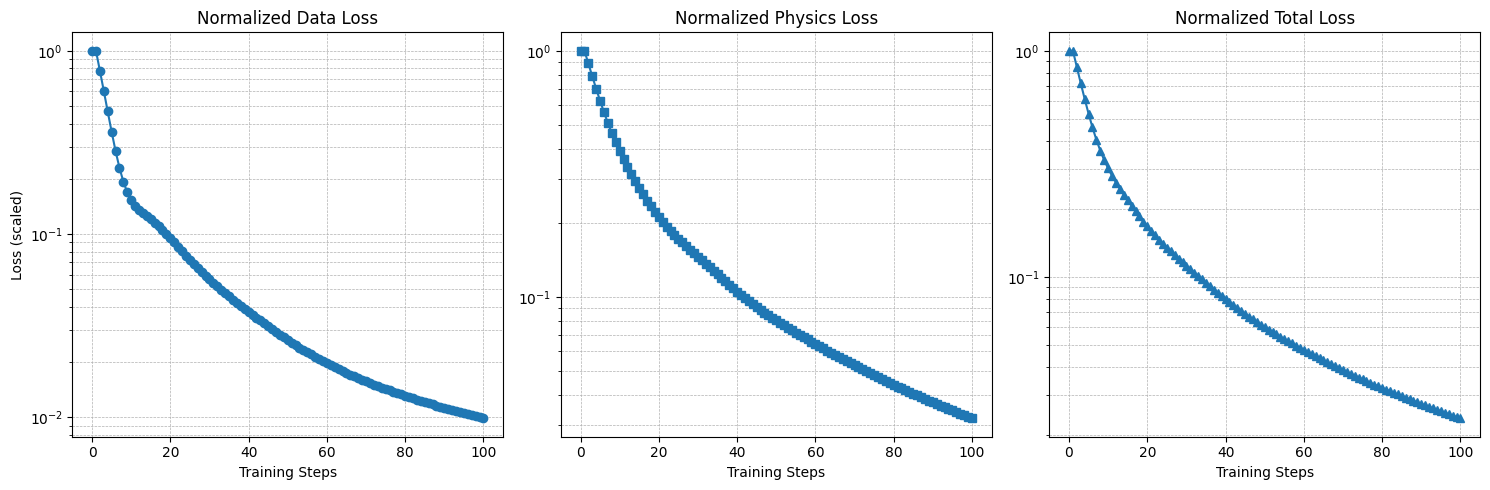

In [12]:
import os
from flax.training import checkpoints
from pinn.utils import assemble_loss_history
from pinn.plot import plot_loss_history, plot_normalized_loss_history

# lambda_1 = 50000.0  # Weight for data loss
# lambda_2 = 0.000    # Weight for physics loss

steps_to_visualize = [0, 20, 40, 60, 80, 100]
# steps_to_visualize = list(range(0, 301, 20))
# steps_to_visualize = list(range(0, 501, 20))
# steps_to_visualize = list(range(0, 1001, 20))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

assembled_loss = assemble_loss_history(checkpoint_data)
plot_loss_history(assembled_loss)
plot_normalized_loss_history(assembled_loss)


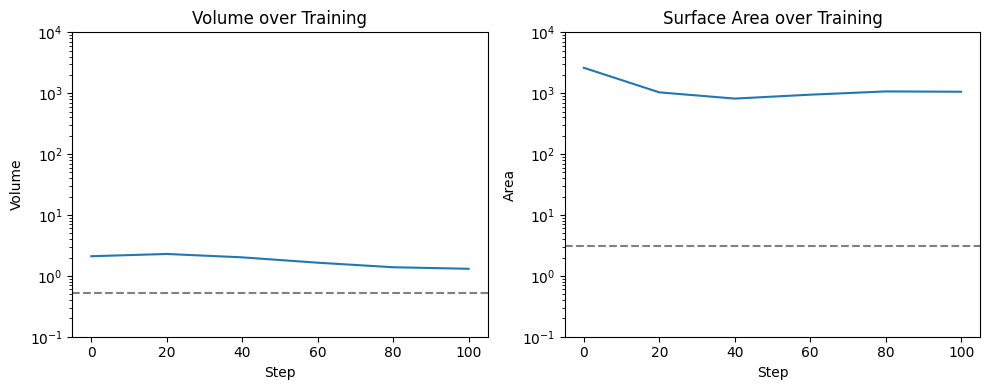

In [3]:
# calculate volume and surface area
from pinn.plot import plot_phase_metrics_ax
import os
import numpy as np
from flax.training import checkpoints
import matplotlib.pyplot as plt

steps_to_visualize = list(range(0, 101, 20))
V_0 = 4*np.pi/3*0.5**3
A_0 = 4*np.pi*0.5**2

# Load checkpoint data
# checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_5000000_0/")
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_5000000_1e-05/")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)


fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot volume
plot_phase_metrics_ax(axs[0], checkpoint_data, metrics="volume", epsilon=0.05, V_0=V_0, grid_size=64)
axs[0].set_title("Volume over Training")

# Plot surface area
plot_phase_metrics_ax(axs[1], checkpoint_data, metrics="area", epsilon=0.05, A_0=A_0, grid_size=64)
axs[1].set_title("Surface Area over Training")

plt.tight_layout()
plt.show()

## Junk code

/Users/atsushi/simulation/pinn-exploration-model/venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Number of vertices: 5106
Number of faces: 10208
X range: -0.5447494089603424 to 0.5053770542144775
Y range: -0.5127099454402924 to 0.4956023693084717
Z range: -0.5464169085025787 to 0.5082932710647583
X grid range: -1.0 to 1.0
Y grid range: -1.0 to 1.0
Z grid range: -1.0 to 1.0
Number of vertices: 6692
Number of faces: 13380
X range: -0.7436728477478027 to 0.7782304286956787
Y range: -0.8327986598014832 to 0.7235375642776489
Z range: -0.3659641146659851 to 0.276400089263916
X grid range: -1.0 to 1.0
Y grid range: -1.0 to 1.0
Z grid range: -1.0 to 1.0
Number of vertices: 6638
Number of faces: 13272
X range: -0.7586789131164551 to 0.7389401197433472
Y range: -0.8274258971214294 to 0.7312231063842773
Z range: -0.35286957025527954 to 0.2788228988647461
X grid range: -1.0 to 1.0
Y grid range: -1.0 to 1.0
Z grid range: -1.0 to 1.0


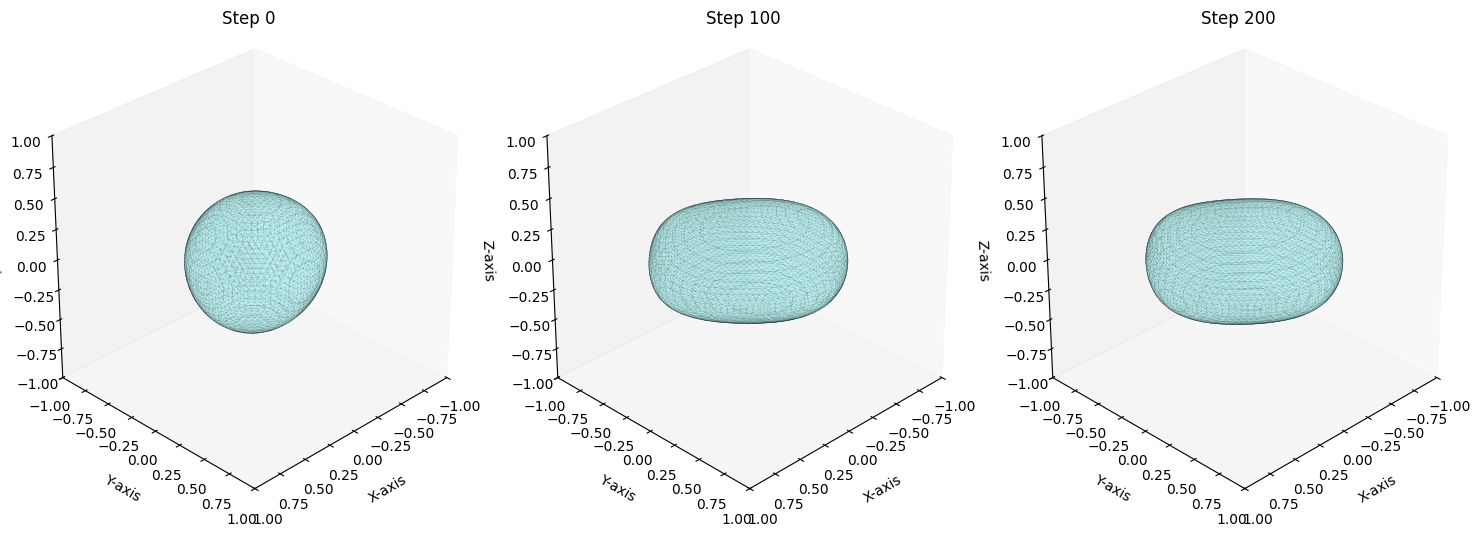

In [26]:
import numpy as np
import os
import jax.numpy as jnp
import matplotlib.pyplot as plt
from pinn.model import PINN
from flax.training import checkpoints
from pinn.plot import plot_3d_isosurface
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def plot_3d_isosurface(ax, step, checkpoint, grid_size=64):
    """
    Load a checkpoint, compute φ values, extract the isosurface, and plot it.

    Args:
        ax: Matplotlib subplot axis to plot on.
        checkpoint_path (str): Path to the checkpoint directory.
        checkpoint_label (str): Label for the plot title.
    """
    # Define normalized coordinate grid (-1 to 1)
    x = jnp.linspace(-1, 1, grid_size)
    y = jnp.linspace(-1, 1, grid_size)
    z = jnp.linspace(-1, 1, grid_size)
    
    # Generate a 3D grid using meshgrid
    X, Y, Z = jnp.meshgrid(x, y, z, indexing="ij")
    grid_points = jnp.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1)
    
    # Load model and parameters
    model = PINN()
    state = checkpoint["state"]
    params = state["params"]
    phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))

    # Compute φ values over a 3D grid
    phi_values = phi_fn(grid_points).reshape(grid_size, grid_size, grid_size)
    phi_values = phi_values.T

    # Convert φ values from JAX to NumPy for visualization
    phi_values_np = np.array(phi_values)

    # Apply marching cubes to extract the isosurface
    verts, faces, _, _ = marching_cubes(phi_values_np, level=0, spacing=(2/grid_size, 2/grid_size, 2/grid_size))
    # verts, faces, _, _ = marching_cubes(phi_values_np, level=0, spacing=(1/grid_size, 1/grid_size, 1/grid_size))
    # verts, faces, _, _ = marching_cubes(phi_values_np, level=0, spacing=(1, 1, 1))

    verts -= 1.0    


    print(f"Number of vertices: {len(verts)}")
    print(f"Number of faces: {len(faces)}")

    print(f"X range: {verts[:, 0].min()} to {verts[:, 0].max()}")
    print(f"Y range: {verts[:, 1].min()} to {verts[:, 1].max()}")
    print(f"Z range: {verts[:, 2].min()} to {verts[:, 2].max()}")
    
    print(f"X grid range: {X.min()} to {X.max()}")
    print(f"Y grid range: {Y.min()} to {Y.max()}")
    print(f"Z grid range: {Z.min()} to {Z.max()}")



    # Add the surface mesh with improved appearance
    mesh = Poly3DCollection(verts[faces], alpha=0.1, edgecolor="k", linewidth=0.2, facecolor="cyan")
    ax.add_collection3d(mesh)

    # Improve visualization by adding a wireframe effect
    # ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2], color="gray", alpha=0.15, edgecolor="black", linewidth=0.05)


    # Set axis labels
    ax.set_xlabel("X-axis", fontsize=10, labelpad=8)
    ax.set_ylabel("Y-axis", fontsize=10, labelpad=8)
    ax.set_zlabel("Z-axis", fontsize=10, labelpad=8)
    ax.set_title(f"Step {step}", fontsize=12)

    # Adjust camera angle & axis limits
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect([1, 1, 1])

    # ax.view_init(elev=0, azim=0)  # Top-down view
    # ax.view_init(elev=90, azim=0)  # Side view
    # ax.view_init(elev=0, azim=90)  # Rotate 90° around Z-axis
    # ax.view_init(elev=45, azim=30)  # Custom view
    ax.view_init(elev=30, azim=45)  # Adjust view angle
    # ax.view_init(elev=180, azim=0)  # Upside down    

    # Improve aesthetics
    ax.grid(False)  # Hide the default grid
    ax.set_facecolor("white")  # Change background color



GRID_SIZE = 64
steps_to_visualize = [0, 100, 200]
# steps_to_visualize = [0, 100, 200, 300, 400, 500]
# steps_to_visualize = [0, 100, 200, 300]

# Load checkpoint data
checkpoint_dir = os.path.abspath("../outputs/checkpoints")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Create a figure with horizontally arranged subplots
fig, axes = plt.subplots(1, len(steps_to_visualize), figsize=(15, 5), subplot_kw={'projection': '3d'})

for i, step in enumerate(steps_to_visualize):
    plot_3d_isosurface(axes[i], step, checkpoint_data[step], grid_size = GRID_SIZE)

plt.tight_layout()
plt.show()


Checkpoint loaded successfully at step 0
Lambda_1: 50000.0, Lambda_2: 0.0


/Users/atsushi/Library/Mobile Documents/com~apple~CloudDocs/simulation/akamatsu/pinn-exploration-model/venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1250: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


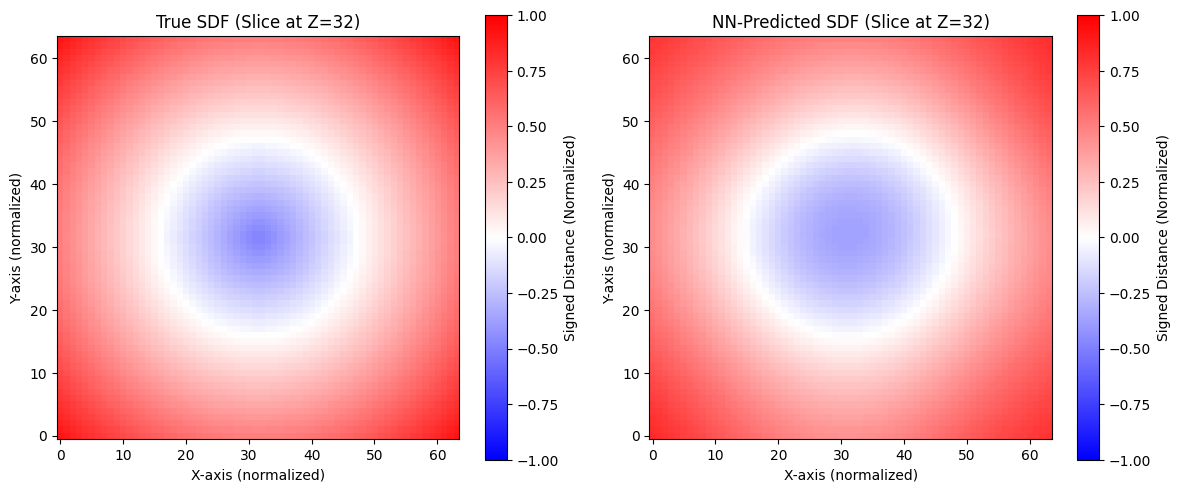

True SDF Min: -0.4725072383880615, Max: 1.2320507764816284
NN-Predicted SDF Min: -0.3651101291179657, Max: 1.1180299520492554


In [35]:
import os
from flax.training import checkpoints
from pinn.model import PINN
from pinn.train import generate_sdf
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Define checkpoint directory
checkpoint_dir = os.path.abspath("../outputs/checkpoints/checkpoint_0")

# Restore checkpoint (automatically loads the latest checkpoint file in the directory)
checkpoint = checkpoints.restore_checkpoint(checkpoint_dir, target=None)

# Extract the saved state
state = checkpoint["state"]

# Print checkpoint details
print(f"Checkpoint loaded successfully at step {state['step']}")
print(f"Lambda_1: {state['lambda_1']}, Lambda_2: {state['lambda_2']}")

# Load the trained PINN model
model = PINN()

# Generate the voxel grid used in SDF pretraining
grid_size = 64  # Match the training grid size
grid_points, true_sdf = generate_sdf(grid_size=grid_size, radius=0.5)

# **Normalize true SDF values using sphere radius**
# true_sdf = true_sdf / 15.0  # Expected range should be [-1,1]

# Compute the neural network's predicted SDF using normalized grid points
predicted_sdf = model.apply(state["params"], grid_points).reshape(grid_size, grid_size, grid_size)

# Select a middle slice for visualization
slice_index = grid_size // 2  # Middle slice at Z=32

# Create side-by-side plots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# **1. True SDF**
img1 = axs[0].imshow(true_sdf[:, :, slice_index].T, cmap="bwr", origin="lower", vmin=-1, vmax=1)
axs[0].set_title("True SDF (Slice at Z=32)")
axs[0].set_xlabel("X-axis (normalized)")
axs[0].set_ylabel("Y-axis (normalized)")
cbar1 = fig.colorbar(img1, ax=axs[0])
cbar1.set_label("Signed Distance (Normalized)")

# **2. NN-Predicted SDF**
img2 = axs[1].imshow(predicted_sdf[:, :, slice_index].T, cmap="bwr", origin="lower", vmin=-1, vmax=1)
axs[1].set_title("NN-Predicted SDF (Slice at Z=32)")
axs[1].set_xlabel("X-axis (normalized)")
axs[1].set_ylabel("Y-axis (normalized)")

# Add colorbar for NN prediction
cbar2 = fig.colorbar(img2, ax=axs[1])
cbar2.set_label("Signed Distance (Normalized)")

plt.tight_layout()
plt.show()

# Print some sample values for numerical comparison
print(f"True SDF Min: {true_sdf.min()}, Max: {true_sdf.max()}")
print(f"NN-Predicted SDF Min: {predicted_sdf.min()}, Max: {predicted_sdf.max()}")


In [3]:
sample_idx = np.random.choice(grid_points.shape[0], 10, replace=False)
pred_values = model.apply(state["params"], grid_points[sample_idx])

print("Sample Grid Points:", grid_points[sample_idx])
print("True SDF Values:", true_sdf.ravel()[sample_idx])
print("NN-Predicted SDF Values:", pred_values)


Sample Grid Points: [[-1.0075586  -1.0075586  -1.0136055 ]
 [-0.9863945  -1.0025195  -1.0045351 ]
 [-0.98236334 -0.98236334 -0.973293  ]
 [-1.0125977  -1.005543   -1.0085664 ]
 [-1.0307382  -0.9753086  -1.0035273 ]
 [-0.973293   -1.0015117  -1.031746  ]
 [-1.0115899  -1.0025195  -0.9874024 ]
 [-1.0065508  -0.9793399  -0.96926177]
 [-0.98337114 -0.99042577 -1.021668  ]
 [-1.0136055  -1.021668   -0.96926177]]
True SDF Values: [ 0.05481059 -0.01394899  0.5374039   0.02744485  0.6137033   0.6620802
  0.05481059  0.56420106  0.34677958  0.6239477 ]
NN-Predicted SDF Values: [0.959193   0.9504752  0.9367666  0.95874846 0.9548949  0.95364535
 0.9526299  0.94128764 0.95101035 0.9532894 ]


Resizing MRC data from (128, 128, 128) to (64, 64, 64)


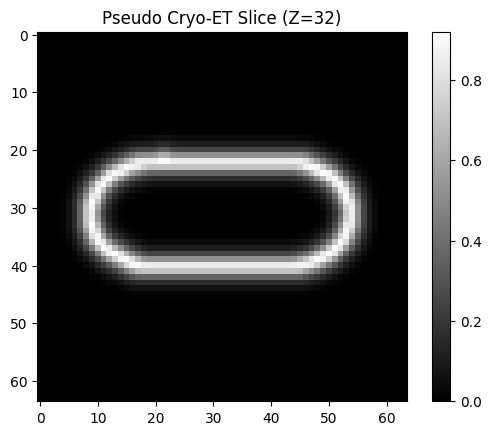

In [10]:
from data_generation.mesh_to_cryoet import plot_single_slice

mrc_file_path = "../data/synthetic/biconcave.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=64)

plot_single_slice(cryoET_data, axis='z')

In [1]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

def visualize_checkpoint_result(ax, step, checkpoint, model, grid_size=64, cryoET_data=None):
    """
    Compute and visualize the level-set function from a given checkpoint.
    """
    state = checkpoint["state"]  # Extract saved model state
    params = state["params"]  # Extract trained parameters

    # Use the model's apply function
    phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))

    # Define the real coordinate values
    x = jnp.linspace(-1.5, 1.5, grid_size)
    y = jnp.linspace(-1.5, 1.5, grid_size)
    z = jnp.linspace(-1.5, 1.5, grid_size)

    # Generate a 3D grid
    X, Y, Z = jnp.meshgrid(x, y, z, indexing="ij")
    grid_points = jnp.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1)
    
    # Compute φ values
    phi_values = phi_fn(grid_points).reshape(grid_size, grid_size, grid_size)

    # Extract the central XY slice at Z=0
    mid_slice = grid_size // 2
    img = ax.imshow(phi_values[:, :, mid_slice].T, cmap='bwr', origin='lower',
                    extent=[x.min(), x.max(), y.min(), y.max()],
                    vmin=-0.5, vmax=0.5, alpha=1.0)

    # Plot the CryoET data as a heatmap if available
    if cryoET_data is not None:
        cryoET_numpy = np.array(cryoET_data[:, :, mid_slice])  # Convert to NumPy for visualization
        alpha_mask = np.where(cryoET_numpy > 0.7, 0.5, 0.0)  # Only show intensities > 0.7
        ax.imshow(np.ones_like(cryoET_numpy), cmap='gray', origin='lower',
                  extent=[x.min(), x.max(), y.min(), y.max()], alpha=alpha_mask)

    # Plot contour lines for φ=0
    contour = ax.contour(X[:, :, mid_slice], Y[:, :, mid_slice],
                         phi_values[:, :, mid_slice], levels=[0], colors='black')

    ax.clabel(contour, fmt="φ=0", colors='black')  # Label contour line

    # Set axis labels
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")

    # Set appropriate tick positions and labels
    tick_positions = jnp.linspace(x.min(), x.max(), num=5)
    tick_labels = [f"{val:.1f}" for val in tick_positions]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)

    ax.set_title(f"Level-Set Function at z=0 (Step {step})")

    return img



In [5]:
step_to_load = 100  # Choose a step
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step_to_load}")

print(checkpoint_path)

# Restore the specific checkpoint
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
print("Keys stored in checkpoint:", checkpoint_data.keys())

print(checkpoint_data['state'].keys())
print(checkpoint_data['loss'].keys())
print(checkpoint_data['loss']['data_loss'].shape)



/Users/atsushi/Library/Mobile Documents/com~apple~CloudDocs/simulation/akamatsu/pinn-exploration-model/outputs/checkpoints/checkpoint_100
Keys stored in checkpoint: dict_keys(['loss', 'state'])
dict_keys(['lambda_1', 'lambda_2', 'opt_state', 'params', 'step'])
dict_keys(['data_loss', 'physics_loss', 'step', 'total_loss'])
(100,)
[0.23663813 0.19605845 0.15963516 0.12750378 0.09976386 0.07646372
 0.05758692 0.04303426 0.03260298 0.02596704 0.02266202 0.02208543
 0.02352078 0.02619107 0.02933641 0.03229746 0.03458191 0.03589546
 0.0361357  0.03535875 0.03373372 0.03149547 0.0289032  0.026207
 0.02362383 0.02132219 0.01941458 0.01795693 0.01695319 0.01636413
 0.01611846 0.01612518 0.01628604 0.01650656 0.01670506 0.01681869
 0.01680668 0.0166506  0.01635251 0.01593123 0.01541751 0.0148487
 0.01426352 0.01369754 0.01317959 0.01272958 0.01235733 0.0120629
 0.01183791 0.01166773 0.01153416 0.01141814 0.01130223 0.01117256
 0.01101995 0.01084044 0.01063487 0.01040798 0.01016711 0.00992077
 0.

/Users/atsushi/Library/Mobile Documents/com~apple~CloudDocs/simulation/akamatsu/pinn-exploration-model/venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [67]:
loss_dict = checkpoint_data['loss']

# Convert to a list of dictionaries (sorted by step order)
loss_history = [loss_dict[key] for key in sorted(loss_dict.keys(), key=int)]

# Convert to Pandas DataFrame for easy analysis
import pandas as pd

df = pd.DataFrame(loss_history)  # Each row corresponds to one saved loss entry
print(df.head())  # Display the first few loss entries


      data_loss     physics_loss  step total_loss
0   0.004596687   244577390000.0   101  229.83435
1  0.0045235488   425832870000.0   102  226.17744
2  0.0044517354   761771850000.0   103  222.58678
3   0.004381244  1402793200000.0   104  219.06221
4  0.0043121297  2665797000000.0   105  215.60649


In [38]:
for step in [100, 200, 300, 400]:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
    print(f"Checkpoint {step}: step stored inside = {data['step']}")


Checkpoint 100: step stored inside = 100
Checkpoint 200: step stored inside = 200
Checkpoint 300: step stored inside = 300
Checkpoint 400: step stored inside = 400
Checkpoint 500: step stored inside = 500


In [15]:
# Restore checkpoint
state_dict = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_dir, target=None)

# Extract trained model parameters
params = state_dict['params']

# Use restored parameters in the model for inference
# output = model.apply(params, some_input_data)

state = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_dir, target=state)
print(f"Resumed training from step {state.step}")

import os
print("Available checkpoints:", os.listdir(checkpoint_dir))


/Users/atsushi/Library/Mobile Documents/com~apple~CloudDocs/simulation/akamatsu/pinn/venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resumed training from step 401
Available checkpoints: ['checkpoint_400']


Available checkpoints: ['checkpoint_400']


In [23]:
import os

# List all files in the checkpoint directory
checkpoint_files = os.listdir(checkpoint_dir)
print("Available checkpoints:", checkpoint_files)


Available checkpoints: ['checkpoint_0', 'checkpoint_100', 'checkpoint_200', 'checkpoint_300', 'checkpoint_400']


Checkpoint restored, ready for visualization.


TypeError: Input z must be 2D, not 3D

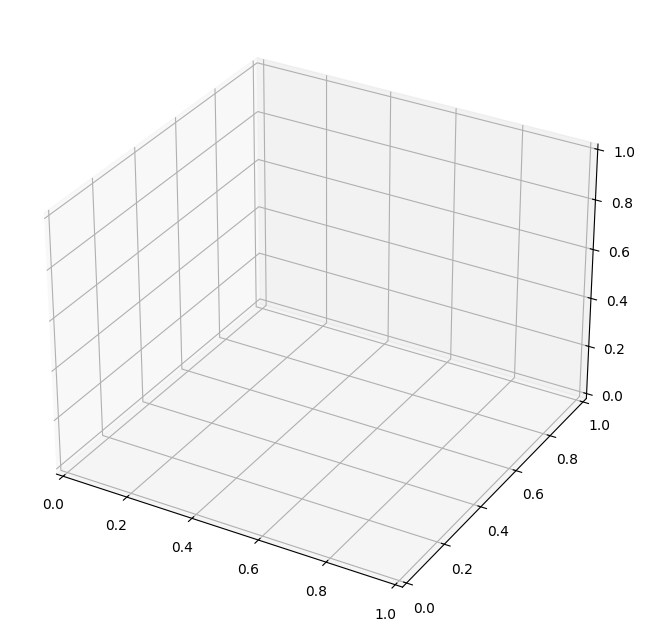

In [6]:
from flax.training import checkpoints

# Restore checkpoint
state = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_dir, target=state)
print("Checkpoint restored, ready for visualization.")

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define a 3D grid
grid_size = 50
x_vals = np.linspace(-1.5, 1.5, grid_size)
y_vals = np.linspace(-1.5, 1.5, grid_size)
z_vals = np.linspace(-1.5, 1.5, grid_size)

X, Y, Z = np.meshgrid(x_vals, y_vals, z_vals)
xyz_grid = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)

# Compute predictions using the restored model
phi_values = state.apply_fn(state.params, xyz_grid)
phi_values = phi_values.reshape(grid_size, grid_size, grid_size)

# Plot an isosurface where φ(x,y,z) = 0
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")
ax.contourf(X, Y, Z, phi_values, levels=[0], cmap="coolwarm")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D Isosurface of φ(x,y,z) = 0")
plt.show()


Model and training state restored successfully!
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
MRC data loaded successfully! Shape: (64, 64, 64)


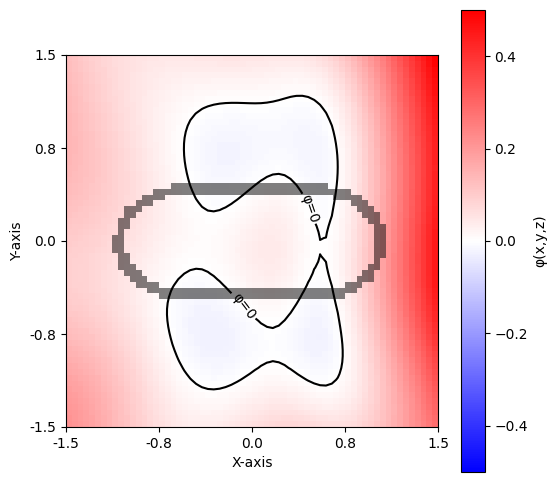

In [8]:
import pickle
import jax
import numpy as np
from pinn.model import PINN
from pinn.train import create_train_state
from pinn.plot import visualize_results
from pinn.cryoet_io import load_mrc_data

# Load trained model parameters
with open("pinn_params.pkl", "rb") as f:
    restored_params = pickle.load(f)

# Load optimizer state (if resuming training)
with open("pinn_opt_state.pkl", "rb") as f:
    restored_opt_state = pickle.load(f)

# Load training step
with open("pinn_step.pkl", "rb") as f:
    restored_step = pickle.load(f)

# Recreate model and training state
key = jax.random.PRNGKey(0)
model = PINN()  # Recreate model architecture
state, _ = create_train_state(key)  # Initialize new state

# Restore parameters and optimizer
state = state.replace(params=restored_params, opt_state=restored_opt_state, step=restored_step)

print("Model and training state restored successfully!")


# Load MRC data 
mrc_file_path = "../data/synthetic/biconcave.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=64)
print("MRC data loaded successfully! Shape:", cryoET_data.shape)


visualize_results(lambda x: state.apply_fn(state.params, x), cryoET_data=cryoET_data)

pixsel